In [41]:
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import shutil
from sklearn.model_selection import train_test_split

In [2]:
DATASET_PATH = Path("../../datasets/LFW")
IMAGE_PATH = DATASET_PATH / "lfw-deepfunneled" / "lfw-deepfunneled"
lfw_allnames = pd.read_csv(DATASET_PATH / "lfw_allnames.csv")
matchpairsDevTest = pd.read_csv(DATASET_PATH / "matchpairsDevTest.csv")
matchpairsDevTrain = pd.read_csv(DATASET_PATH / "matchpairsDevTrain.csv")
mismatchpairsDevTest = pd.read_csv(DATASET_PATH / "mismatchpairsDevTest.csv")
mismatchpairsDevTrain = pd.read_csv(DATASET_PATH / "mismatchpairsDevTrain.csv")
pairs = pd.read_csv(DATASET_PATH / "pairs.csv")
people = pd.read_csv(DATASET_PATH / "people.csv")
peopleDevTest = pd.read_csv(DATASET_PATH / "peopleDevTest.csv")
peopleDevTrain = pd.read_csv(DATASET_PATH / "peopleDevTrain.csv")

In [3]:
print(lfw_allnames.shape)
print(matchpairsDevTrain.shape)
print(mismatchpairsDevTrain.shape)
print(pairs.shape)
print(people.shape)

(5749, 2)
(1100, 3)
(1100, 4)
(6000, 4)
(5758, 2)


In [4]:
lfw_allnames.loc[lfw_allnames.images.idxmax()]

name      George_W_Bush
images              530
Name: 1871, dtype: object

In [5]:
lfw_allnames.name.unique()

<StringArray>
[           'AJ_Cook',           'AJ_Lamas',      'Aaron_Eckhart',
        'Aaron_Guiel',    'Aaron_Patterson',      'Aaron_Peirsol',
         'Aaron_Pena',       'Aaron_Sorkin',       'Aaron_Tippin',
          'Abba_Eban',
 ...
               'Zico',    'Zinedine_Zidane',          'Ziwang_Xu',
           'Zoe_Ball',     'Zoran_Djindjic',     'Zorica_Radovic',
     'Zulfiqar_Ahmed',       'Zumrati_Juma',    'Zurab_Tsereteli',
 'Zydrunas_Ilgauskas']
Length: 5749, dtype: str

In [6]:
image_paths = lfw_allnames.loc[lfw_allnames.index.repeat(lfw_allnames['images'])]
image_paths

,name,images
0,AJ_Cook,1
1,AJ_Lamas,1
2,Aaron_Eckhart,1
3,Aaron_Guiel,1
4,Aaron_Patterson,1
...,...,...
5744,Zorica_Radovic,1
5745,Zulfiqar_Ahmed,1
5746,Zumrati_Juma,1
5747,Zurab_Tsereteli,1


In [7]:
image_paths['image_path'] = 1 + image_paths.groupby('name').cumcount()
image_paths['image_path'] = image_paths.image_path.apply(lambda x: '{0:0>4}'.format(x))
image_paths['image_path'] = image_paths.name + "/" + image_paths.name + "_" + image_paths.image_path + ".jpg"
image_paths = image_paths.drop(columns=["images"])
image_paths

,name,image_path
0,AJ_Cook,AJ_Cook/AJ_Cook_0001.jpg
1,AJ_Lamas,AJ_Lamas/AJ_Lamas_0001.jpg
2,Aaron_Eckhart,Aaron_Eckhart/Aaron_Eckhart_0001.jpg
3,Aaron_Guiel,Aaron_Guiel/Aaron_Guiel_0001.jpg
4,Aaron_Patterson,Aaron_Patterson/Aaron_Patterson_0001.jpg
...,...,...
5744,Zorica_Radovic,Zorica_Radovic/Zorica_Radovic_0001.jpg
5745,Zulfiqar_Ahmed,Zulfiqar_Ahmed/Zulfiqar_Ahmed_0001.jpg
5746,Zumrati_Juma,Zumrati_Juma/Zumrati_Juma_0001.jpg
5747,Zurab_Tsereteli,Zurab_Tsereteli/Zurab_Tsereteli_0001.jpg


In [8]:
from PIL import Image
widths = []
heights = []
files = image_paths.image_path
for file in files:
    path = IMAGE_PATH / file
    im = Image.open(path)
    widths.append(im.width)
    heights.append(im.height)

pd.DataFrame({'height':heights,'width':widths}).describe()

,height,width
count,13233.0,13233.0
mean,250.0,250.0
std,0.0,0.0
min,250.0,250.0
25%,250.0,250.0
50%,250.0,250.0
75%,250.0,250.0
max,250.0,250.0


<Axes: xlabel='name'>

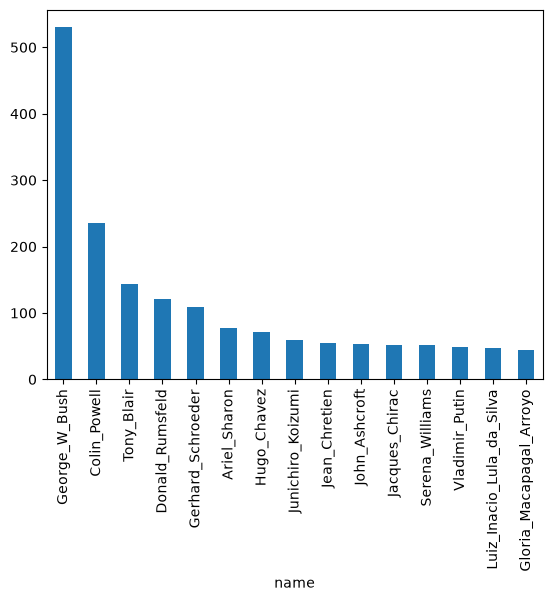

In [9]:
image_paths['name'].value_counts()[:15].plot(kind = "bar")

In [10]:
not_george = image_paths[image_paths.name!="George_W_Bush"].sample(len(image_paths[image_paths.name=="George_W_Bush"]))
not_george.name = "not_George"
GWB_data = pd.concat([image_paths[image_paths.name=="George_W_Bush"],
                     not_george])

In [11]:
bush_train, bush_test = train_test_split(GWB_data, test_size=0.2)
bush_train, bush_val = train_test_split(bush_train,test_size=0.2)

In [52]:
Bush_classifier = tf.keras.models.Sequential()
Bush_classifier.add(
    tf.keras.Input((250, 250, 3))
)
Bush_classifier.add(tf.keras.layers.RandomFlip("horizontal"))
Bush_classifier.add(tf.keras.layers.RandomZoom(0.1))
Bush_classifier.add(tf.keras.layers.Conv2D(
    32,
    (3,3),
    activation="relu"
))
Bush_classifier.add(tf.keras.layers.MaxPooling2D(
    pool_size=(2,2)
))
Bush_classifier.add(tf.keras.layers.Flatten())
Bush_classifier.add(tf.keras.layers.Dense(
    units=128,
    activation="relu"
))
Bush_classifier.add(tf.keras.layers.Dense(
    units=1,
    activation="sigmoid"
))
Bush_classifier.compile(
    optimizer="adam",
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[tf.keras.metrics.BinaryAccuracy()]
)

In [20]:
def directory_mover(data, dir_name):
    destination_root = DATASET_PATH / dir_name
    destination_root.mkdir(parents=True, exist_ok=True)
    count = 0
    for image, person in zip(data["image_path"], data["name"]):
        person_dir = destination_root / person
        person_dir.mkdir(exist_ok=True)
        source = IMAGE_PATH / image
        destination = person_dir / Path(image).name
        shutil.copy(source, destination)
        count += 1
    print(f"Moved {count} images to {dir_name} folder.")

In [21]:
directory_mover(bush_train,"Bush_train")
directory_mover(bush_test,"Bush_test")

Moved 678 images to Bush_train folder.
Moved 212 images to Bush_test folder.


In [26]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH / "Bush_train",
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(250, 250),
    batch_size=32
)

Found 678 files belonging to 2 classes.
Using 543 files for training.


In [27]:
val_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH / "Bush_train",
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(250, 250),
    batch_size=32
)

Found 678 files belonging to 2 classes.
Using 135 files for validation.


In [24]:
test_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH / "Bush_test",
    image_size=(250,250),
    batch_size=16,
    shuffle=False
)

Found 212 files belonging to 2 classes.


In [39]:
bush_history = Bush_classifier.fit(
    train_dataset, 
    epochs=20, 
    validation_data=val_dataset
)

Epoch 1/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 11s 629ms/step - binary_accuracy: 0.9521 - loss: 0.5300 - val_binary_accuracy: 0.8519 - val_loss: 4.8558
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 11s 627ms/step - binary_accuracy: 0.9245 - loss: 1.1493 - val_binary_accuracy: 0.8296 - val_loss: 4.2757
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 11s 626ms/step - binary_accuracy: 0.9576 - loss: 0.5901 - val_binary_accuracy: 0.8593 - val_loss: 2.9050
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 11s 631ms/step - binary_accuracy: 0.9742 - loss: 0.2761 - val_binary_accuracy: 0.8222 - val_loss: 5.2627
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 11s 632ms/step - binary_accuracy: 0.9484 - loss: 0.5834 - val_binary_accuracy: 0.8667 - val_loss: 2.0371
Epoch 6/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 11s 626ms/step - binary_accuracy: 0.9742 - loss: 0.2331 - val_binary_accuracy: 0.8593 - val_loss: 2.6753
Epoch 7/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 11s 630ms/step - binary_accuracy: 0.9761 - loss: 0.2267 - val_binary_accuracy: 0.8370 - val_loss: 3.5207

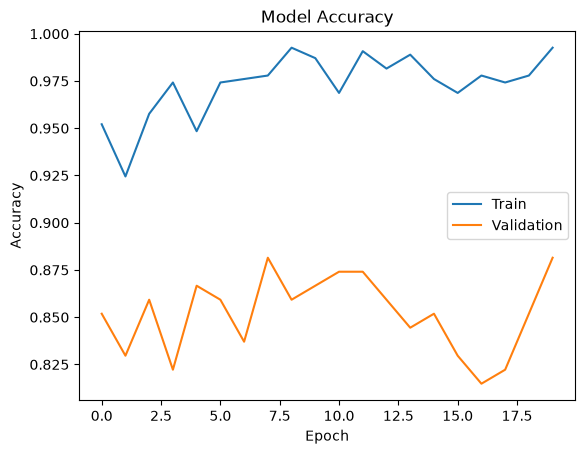

In [50]:
plt.plot(bush_history.history["binary_accuracy"])
plt.plot(bush_history.history["val_binary_accuracy"])

plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(["Train", "Validation"])
plt.show()

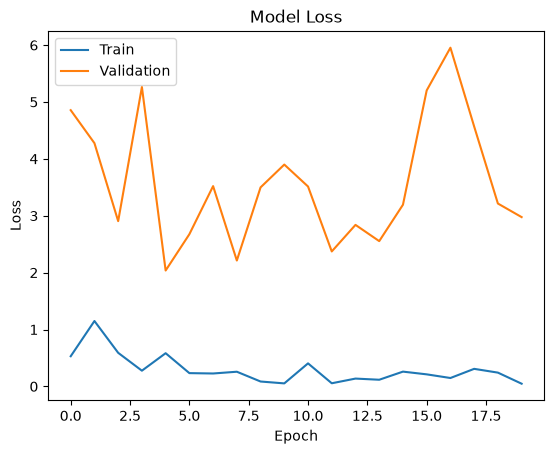

In [51]:
plt.plot(bush_history.history["loss"])
plt.plot(bush_history.history["val_loss"])

plt.title("Model Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend(["Train", "Validation"])
plt.show()